**코호트 (하한 60세 ver.): 65세 이상 + (60세 이상 65세 미만) AND 노인성질환 보유**

In [29]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
admission = pd.read_csv('admissions.csv.gz', compression='gzip')
patients = pd.read_csv('patients.csv.gz', compression='gzip')
transfer = pd.read_csv('transfers.csv.gz', compression='gzip')
diagnoses = pd.read_csv('diagnoses_icd.csv.gz', compression='gzip')

# 나이 계산
df = pd.merge(admission[['subject_id', 'hadm_id', 'admittime']], 
              patients[['subject_id', 'anchor_age', 'anchor_year']], on='subject_id')
df['age'] = df['anchor_age'] + (pd.to_datetime(df['admittime']).dt.year - df['anchor_year'])

# --- Step 1: ICU 입실 이력 제외 ---
icu_related_units = 'ICU|SICU|MICU|CCU'
icu_hadm = transfer[transfer['careunit'].str.contains(icu_related_units, na=False, case=False)]['hadm_id'].unique()
df_non_icu = df[~df['hadm_id'].isin(icu_hadm)].copy()

# --- 노인성 질환 코드 정의 ---
dementia_codes = ('F00', 'F01', 'F02', 'F03')
geriatric_codes = (
    'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 
    'G20', 'G21', 'G22', 'G23', 'U234', 'R251', 'G12', 'G13', 'G35', 'G30'
)
all_target_codes = dementia_codes + geriatric_codes

# 질환 보유 hadm_id 추출
all_geriatric_hadm = diagnoses[diagnoses['icd_code'].str.startswith(all_target_codes)]['hadm_id'].unique()

# --- Step 2: 기준 적용 (65세 이상 OR 60-64세 & 질환자) ---

# 조건 1: 65세 이상 전체
cond_65_plus = (df_non_icu['age'] >= 65)

# 조건 2: 60세 이상 65세 미만 AND 노인성 질환 보유
cond_60_64_geriatric = (df_non_icu['age'] >= 60) & (df_non_icu['age'] < 65) & (df_non_icu['hadm_id'].isin(all_geriatric_hadm))

# 최종 합치기 (OR 조건)
cohort_60 = df_non_icu[cond_65_plus | cond_60_64_geriatric].copy()

# 1) 대상 환자들의 모든 노인성 질환 코드를 쉼표로 결합
target_diag_all = diagnoses[diagnoses['icd_code'].str.startswith(all_target_codes)].copy()
diag_combined = target_diag_all.groupby('hadm_id')['icd_code'].apply(
    lambda x: ', '.join(sorted(x.unique()))
).reset_index().rename(columns={'icd_code': 'diagnoses'})

# 2) 대상 환자들의 첫 번째 careunit 정보 가져오기
transfer_first = transfer.sort_values(by=['hadm_id', 'intime']).groupby('hadm_id').first().reset_index()

# 3) 최종 결합
final_output = pd.merge(cohort_60, transfer_first[['hadm_id', 'careunit']], on='hadm_id', how='left')
final_output = pd.merge(final_output, diag_combined, on='hadm_id', how='left')

# 결측치 처리 (노인성 질환 코드가 없는 65세 이상 환자용)
final_output['diagnoses'] = final_output['diagnoses'].fillna('None')

# 요청하신 컬럼만 선택
final_output = final_output[['subject_id', 'hadm_id', 'age', 'careunit', 'diagnoses']]

# --- 결과 출력 ---
print(f"1) 전체 ICU 미입실 환자 건수: {len(df_non_icu):,}")
print(f"2) [그룹 A] 65세 이상 환자: {len(df_non_icu[cond_65_plus]):,}")
print(f"3) [그룹 B] 60-64세 노인성 질환자: {len(df_non_icu[cond_60_64_geriatric]):,}")
print(f"4) 최종 통합 코호트 N: {len(final_output):,}")

# --- Step 3: CSV 파일로 반출 ---
final_output.to_csv('cohort_60.csv', index=False)
print("\n성공: 'cohort_60.csv' 파일로 저장되었습니다.")

1) 전체 ICU 미입실 환자 건수: 460,780
2) [그룹 A] 65세 이상 환자: 186,684
3) [그룹 B] 60-64세 노인성 질환자: 1,962
4) 최종 통합 코호트 N: 188,646

성공: 'cohort_60.csv' 파일로 저장되었습니다.


**컬럼 결측치 확인**
* 최종 코호트(cohort_60, patients, diagnoses_icd, labevents, chartevents, prescriptions)

In [43]:
import pandas as pd
import numpy as np

data = pd.read_csv("cohort.csv")

print(f"### 1. 데이터 기본 정보 ###")
print(f"전체 행 수: {data.shape[0]:,}")
print(f"전체 열 수: {data.shape[1]}")
print("-" * 50)

print("### 2. 변수별 결측치 현황 ###")
missing_info = data.isnull().sum().to_frame(name='결측치 수')
missing_info['결측률(%)'] = (missing_info['결측치 수'] / len(data) * 100).round(2)
display(missing_info[missing_info['결측치 수'] > 0].sort_values(by='결측치 수', ascending=False))

### 1. 데이터 기본 정보 ###
전체 행 수: 187,013
전체 열 수: 20
--------------------------------------------------
### 2. 변수별 결측치 현황 ###


,결측치 수,결측률(%)
BMI,186581,99.77
WEIGHT,184593,98.71
CRP,176489,94.37
ALBUMIN,139014,74.33
TOTAL_PROTEIN,121450,64.94
LYMPHOCYTES,31988,17.10


**행 결측치 확인**

In [ ]:
import pandas as pd

# 1. 데이터 로드
data = pd.read_csv("cohort.csv")

# 2. 각 행(row)별 결측치 비율 계산
missing_ratio_per_row = data.isnull().mean(axis=1)

# 3. 결측치 비율이 70% (0.7) 이상인 행 필터링
threshold = 0.7
high_missing_data = data[missing_ratio_per_row >= threshold]

# 4. 결과 출력
print(f"전체 대상자 수: {len(data):,}")
print(f"결측치 {threshold*100}% 이상인 행 수: {len(high_missing_data):,}")
print(f"비율: {(len(high_missing_data) / len(data)) * 100:.2f}%")

전체 대상자 수: 187,013
결측치 70.0% 이상인 행 수: 0
비율: 0.00%


**결측치 상위 5개 확인 및 이상치 박스플랏으로 확인**

C:\Users\KDT_22\AppData\Local\Temp\ipykernel_8060\394468105.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_missing.values, y=top_5_missing.index, palette=custom_palette)


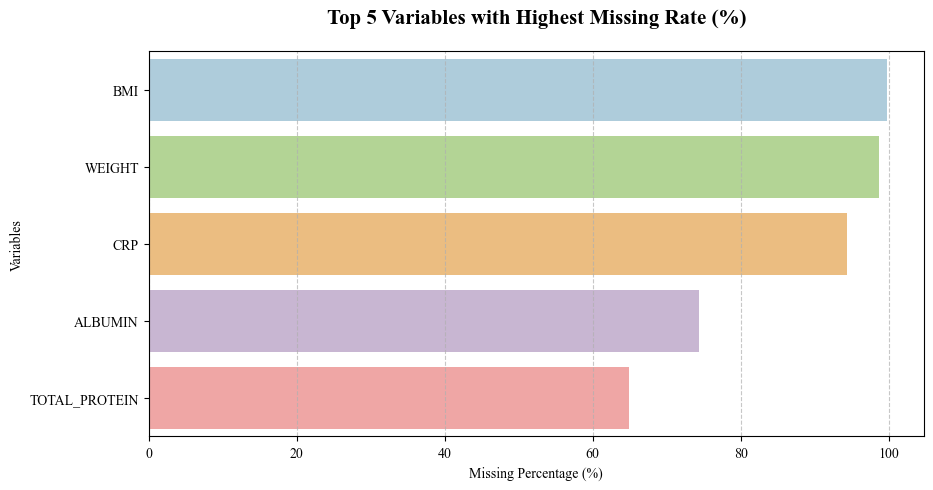

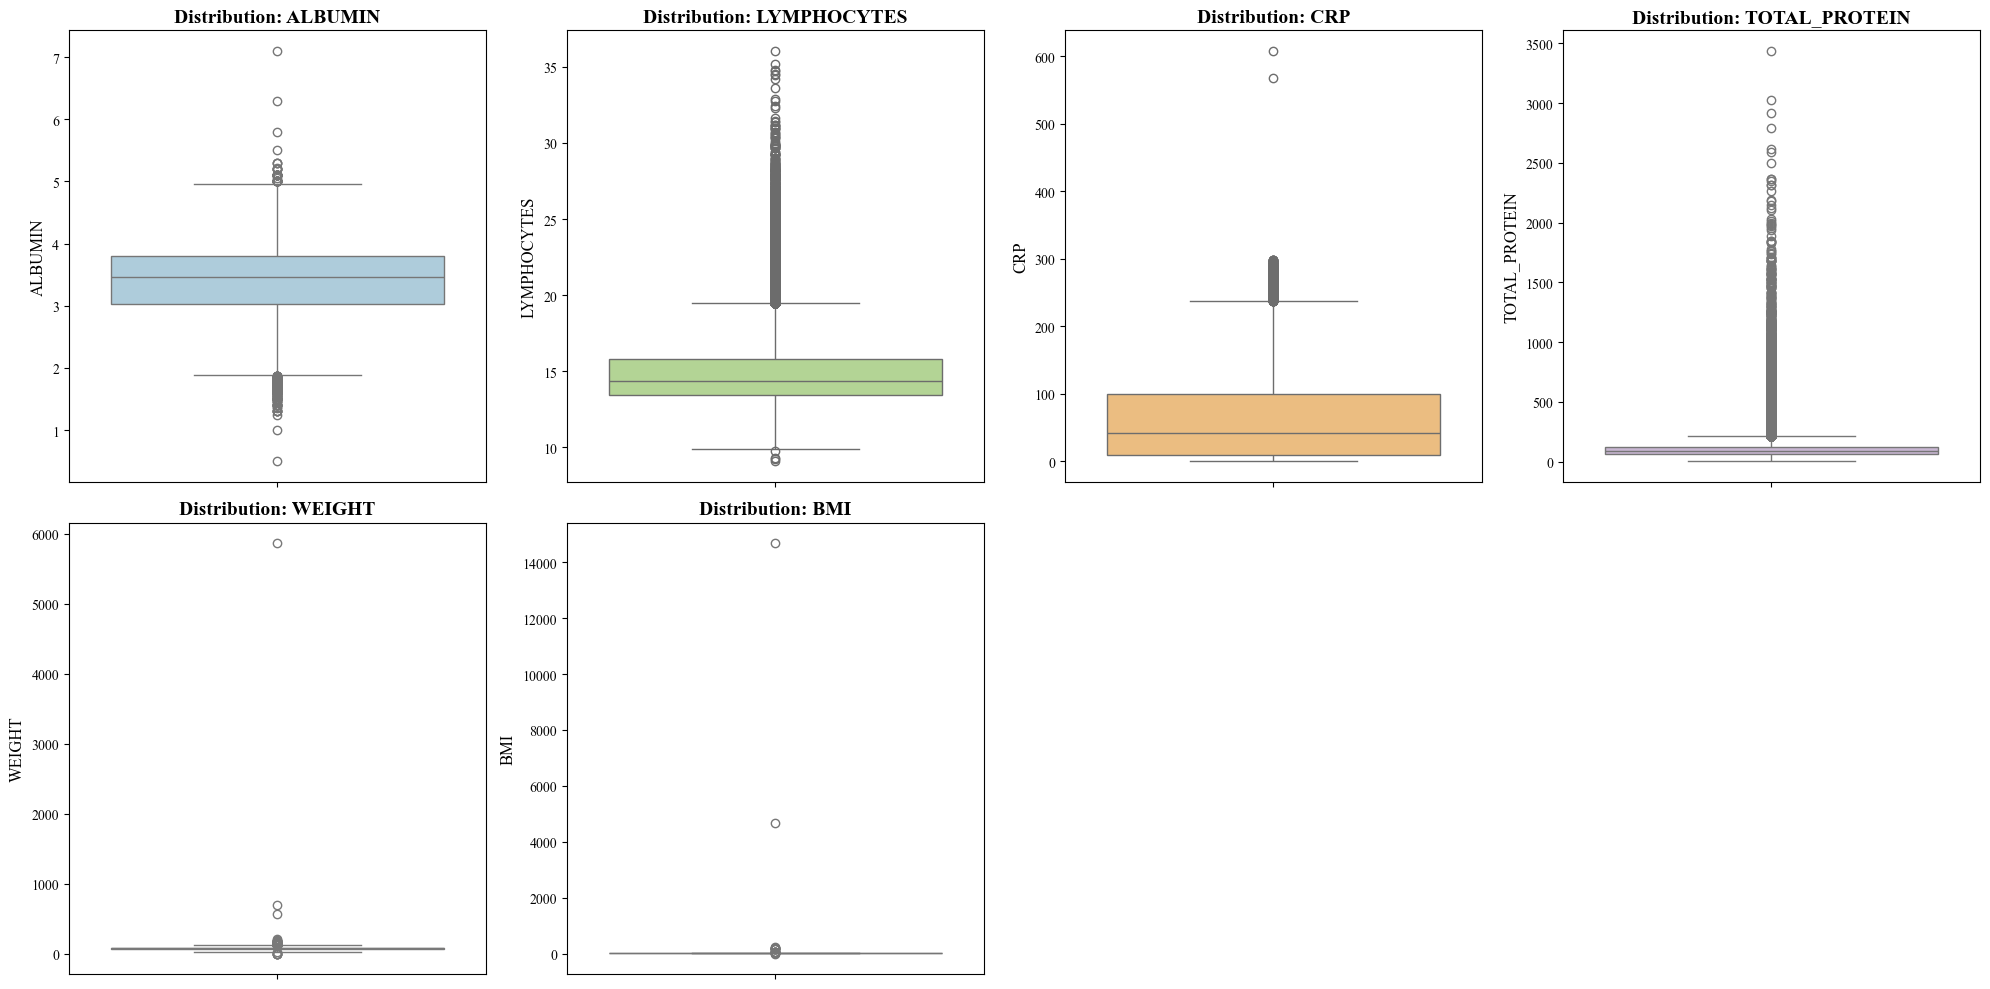

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드, 색상 및 폰트 설정
data = pd.read_csv("cohort.csv")
custom_palette = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#CAB2D6', '#FB9A99']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1) 결측치 비율 상위 5개 변수 시각화
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
missing_pct = data.isnull().mean() * 100
top_5_missing = missing_pct.sort_values(ascending=False).head(5)

sns.barplot(x=top_5_missing.values, y=top_5_missing.index, palette=custom_palette)
plt.title('Top 5 Variables with Highest Missing Rate (%)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# 2) 주요 수치형 변수 박스플롯
# ---------------------------------------------------------
target_vars = ['ALBUMIN', 'LYMPHOCYTES', 'CRP', 'TOTAL_PROTEIN', 'WEIGHT', 'BMI']
actual_cols = data.columns.tolist()
numeric_vars = [col for col in actual_cols if col.upper() in target_vars]

n_vars = len(numeric_vars)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

for idx in range(len(axes)):
    if idx < n_vars:
        var = numeric_vars[idx]
        valid_data = data[var].dropna()
        
        if valid_data.empty:
            axes[idx].text(0.5, 0.5, f'{var}\n(All Missing)', ha='center', va='center')
        else:
            color_idx = idx % len(custom_palette)
            sns.boxplot(y=valid_data, ax=axes[idx], color=custom_palette[color_idx])
            
            axes[idx].set_title(f'Distribution: {var}', fontsize=14, fontweight='bold')
            axes[idx].set_ylabel(var, fontsize=12)
    else:
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

**범주형 변수 EDA**

C:\Users\KDT_22\AppData\Local\Temp\ipykernel_8060\4103306478.py:39: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=plot_series, ax=axes[idx], palette=custom_palette, hue=plot_series, legend=False)
C:\Users\KDT_22\AppData\Local\Temp\ipykernel_8060\4103306478.py:39: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=plot_series, ax=axes[idx], palette=custom_palette, hue=plot_series, legend=False)
C:\Users\KDT_22\AppData\Local\Temp\ipykernel_8060\4103306478.py:39: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=plot_series, ax=axes[idx], palette=custom_palette, hue=plot_series, legend=False)
C:\Users\KDT_22\AppData\Local\Temp\ipykernel_8060\4103306478.py:39: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=plot_series, ax=axes[idx], palette

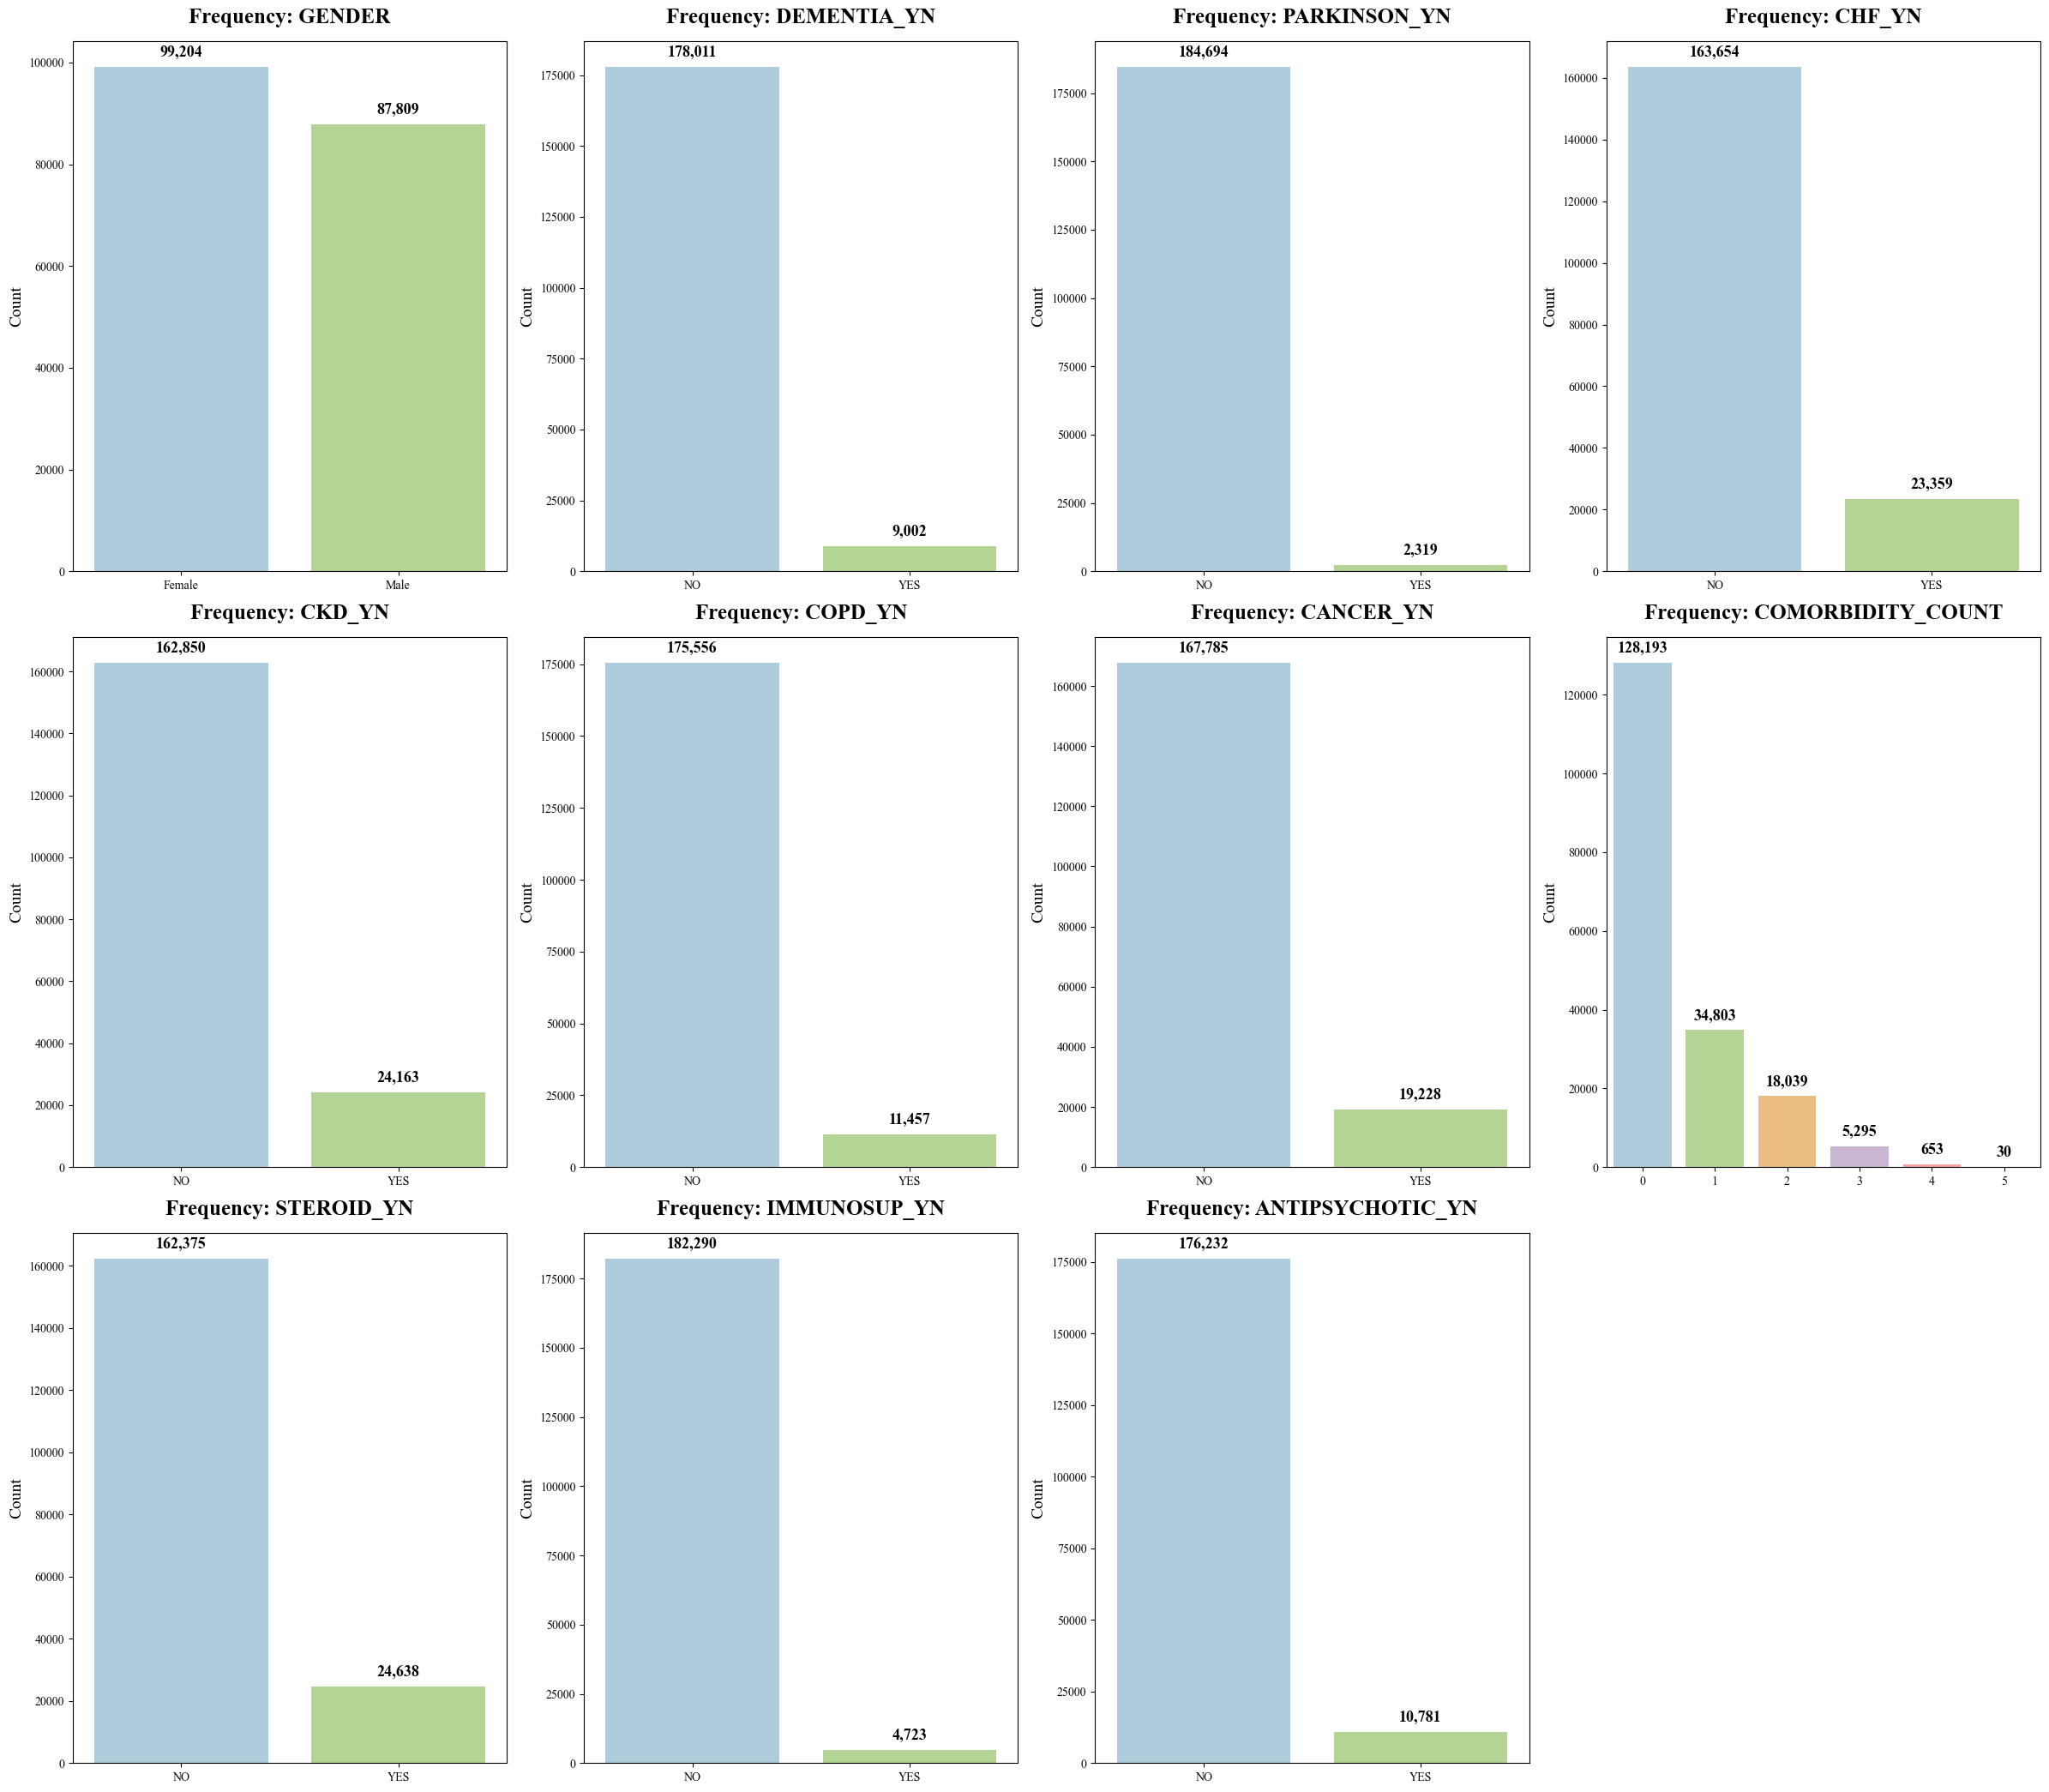

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드, 색상 및 폰트 설정
data = pd.read_csv("cohort.csv")
custom_palette = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#CAB2D6', '#FB9A99']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# 2. 시각화 대상 변수 정의
disease_vars = ['DEMENTIA_YN', 'PARKINSON_YN', 'CHF_YN', 'CKD_YN', 'COPD_YN', 'CANCER_YN']
med_vars = ['STEROID_YN', 'IMMUNOSUP_YN', 'ANTIPSYCHOTIC_YN']
gender_var = ['GENDER']
other_vars = ['COMORBIDITY_COUNT']

actual_cat_vars = [col for col in data.columns if col in (disease_vars + med_vars + gender_var + other_vars)]

# 3. 그래프 레이아웃 설정
n_vars = len(actual_cat_vars)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 7 * n_rows))
axes = axes.flatten()

for idx in range(len(axes)):
    if idx < n_vars:
        var = actual_cat_vars[idx]
        plot_series = data[var].copy()
        
        if var in (disease_vars + med_vars):
            plot_series = plot_series.map({0: 'NO', 1: 'YES'})
        elif var in gender_var:
            plot_series = plot_series.map({'F': 'Female', 'M': 'Male'})

        # 빈도 그래프 그리기
        sns.countplot(x=plot_series, ax=axes[idx], palette=custom_palette, hue=plot_series, legend=False)
        
        # 제목 및 라벨 설정
        axes[idx].set_title(f'Frequency: {var}', fontsize=18, fontweight='bold', pad=15)
        axes[idx].set_ylabel('Count', fontsize=14)
        axes[idx].set_xlabel('') 

        # 막대 위 빈도수 표시 (천 단위 콤마)
        for p in axes[idx].patches:
            height = p.get_height()
            if height > 0:
                axes[idx].annotate(f'{int(height):,}', 
                                   (p.get_x() + p.get_width() / 2., height), 
                                   ha='center', va='center', 
                                   xytext=(0, 12), 
                                   textcoords='offset points',
                                   fontsize=13, fontweight='bold')
    else:
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

**이상치 처리**
* 이상치 처리 권장 범위: MIMIC-IV 가이드라인을 참고하여 임상적으로 가능한 범위로 설정
  
  -- Albumin (1.0-6.0, g/dL), Total protein (30-120, g/L), Lymphocytes (1-80, %), CRP (0-300, mg/dL)

In [6]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
data = pd.read_csv("cohort.csv")

# 2. 분석에서 제외할 변수 삭제 (결측치 과다)
# WEIGHT와 BMI를 리스트에서 제거하여 분석 대상에서 제외합니다.
data_filtered = data.drop(columns=['WEIGHT', 'BMI'], errors='ignore')

# 3. 임상적 정상 범위 설정 (사용자 지정 기준)
clinical_bounds = {
    'ALBUMIN': (1.0, 6.0),
    'TOTAL_PROTEIN': (30, 120),
    'LYMPHOCYTES': (1, 80),
    'CRP': (0, 300)
}

for var, (lower, upper) in clinical_bounds.items():
    # 컬럼 존재 여부 확인
    col_name = next((c for c in data_filtered.columns if c.upper() == var), None)
    
    if col_name:
        # 범위를 벗어나는 행 찾기
        out_of_range = (data_filtered[col_name] < lower) | (data_filtered[col_name] > upper)
        outlier_count = out_of_range.sum()
        
        if outlier_count > 0:
            # 범위를 벗어나는 값만 NaN으로 변경
            data_filtered.loc[out_of_range, col_name] = np.nan
            print(f"[{col_name}] 범위를 벗어나는 {outlier_count}건을 결측 처리함 (기준: {lower}~{upper})")
        else:
            print(f"[{col_name}] 모든 데이터가 지정된 범위 내에 있습니다.")
    else:
        print(f"[{var}] 데이터셋에서 해당 컬럼을 찾을 수 없습니다.")

# 4. 정제된 데이터 저장
data_filtered.to_csv("cohort_preprocess.csv", index=False)

[ALBUMIN] 범위를 벗어나는 3건을 결측 처리함 (기준: 1.0~6.0)
[TOTAL_PROTEIN] 범위를 벗어나는 17762건을 결측 처리함 (기준: 30~120)
[LYMPHOCYTES] 모든 데이터가 지정된 범위 내에 있습니다.
[CRP] 범위를 벗어나는 2건을 결측 처리함 (기준: 0~300)


**(이상치 처리 후) 결측치 상위 5개 및 이상치 박스플랏 확인**

C:\Users\KDT_22\AppData\Local\Temp\ipykernel_8060\1556932380.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_missing.values, y=top_5_missing.index, palette=custom_palette)


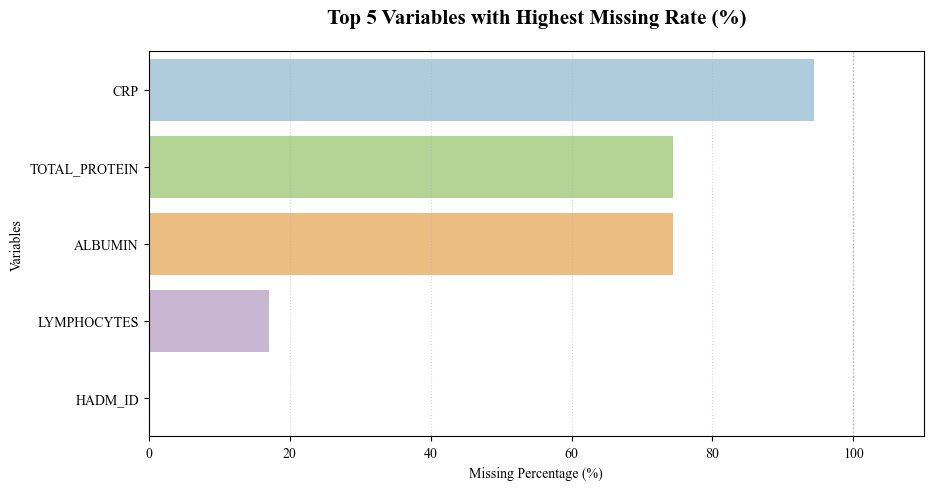

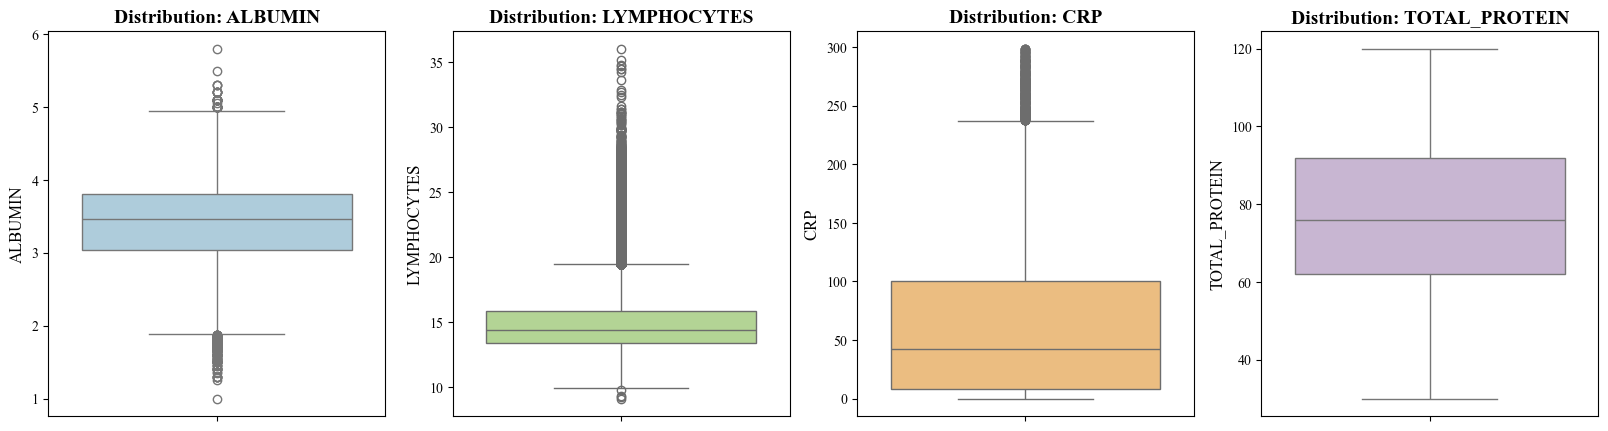

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드, 색상 및 폰트 설정
data = pd.read_csv("cohort_preprocess.csv")
custom_palette = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#CAB2D6', '#FB9A99']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1) 결측치 비율 상위 5개 변수 시각화
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
missing_pct = data.isnull().mean() * 100
top_5_missing = missing_pct.sort_values(ascending=False).head(5)

sns.barplot(x=top_5_missing.values, y=top_5_missing.index, palette=custom_palette)

plt.axvline(x=100, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.xticks([0, 20, 40, 60, 80, 100])
plt.xlim(0, 110)

plt.title('Top 5 Variables with Highest Missing Rate (%)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Variables')

plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()

# ---------------------------------------------------------
# 2) 주요 수치형 변수 박스플롯
# ---------------------------------------------------------
target_vars = ['ALBUMIN', 'LYMPHOCYTES', 'CRP', 'TOTAL_PROTEIN',]
actual_cols = data.columns.tolist()
numeric_vars = [col for col in actual_cols if col.upper() in target_vars]

n_vars = len(numeric_vars)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

for idx in range(len(axes)):
    if idx < n_vars:
        var = numeric_vars[idx]
        valid_data = data[var].dropna()
        
        if valid_data.empty:
            axes[idx].text(0.5, 0.5, f'{var}\n(All Missing)', ha='center', va='center')
        else:
            color_idx = idx % len(custom_palette)
            sns.boxplot(y=valid_data, ax=axes[idx], color=custom_palette[color_idx])
            
            axes[idx].set_title(f'Distribution: {var}', fontsize=14, fontweight='bold')
            axes[idx].set_ylabel(var, fontsize=12)
    else:
        fig.delaxes(axes[idx])

**결측치 대체**
* CRP: indicator only
* Albumin, Total Protein: median with indicator
* Lymphocytes: mice only

In [45]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. 데이터 로드
df = pd.read_csv("cohort_preprocess.csv")

# 2. 변수별 처리 방식 설정
# CRP: 지표만 생성 (값은 결측 유지)
# Albumin, Total Protein: 중앙값 대체 + 지표 생성
# Lymphocytes: MICE 대체 (지표 생성 안 함)
target_vars = {
    'CRP': 'indicator_only',
    'ALBUMIN': 'median_with_indicator',
    'TOTAL_PROTEIN': 'median_with_indicator',
    'LYMPHOCYTES': 'mice_only'
}

print("### 1단계: 지표 생성 및 중앙값 대체 시작 ###")

for var, method in target_vars.items():
    col = next((c for c in df.columns if c.upper() == var), None)
    
    if col:
        # CRP, Albumin, Total Protein에 대해서만 지표(nan_yn) 생성
        if method != 'mice_only':
            df[f'{col}_nan_yn'] = df[col].isnull().astype(int)
        
        # 중앙값 대체 적용
        if method == 'median_with_indicator':
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"[{col}] 중앙값({median_val:.2f}) 대체 및 지표 생성 완료")
        elif method == 'mice_only':
            print(f"[{col}] MICE 대기 중 (지표 생성 생략)")
        else:
            print(f"[{col}] 지표 생성 완료 (원래 값 유지)")

print("\n### 2단계: Lymphocyte MICE 실행 ###")

col_lym = next((c for c in df.columns if c.upper() == 'LYMPHOCYTES'), None)

if col_lym:
    # 림프구 대치를 위해 참고할 변수들
    reference_cols = ['AGE', 'ALBUMIN', 'TOTAL_PROTEIN']
    impute_features = [col_lym] + [c for c in reference_cols if c in df.columns]
    
    mice_imputer = IterativeImputer(max_iter=10, random_state=42)
    # 림프구 값을 채움
    df[impute_features] = mice_imputer.fit_transform(df[impute_features])
    print(f"[{col_lym}] MICE 다중 대치 완료 (결측 지표 없음)")

# 3. 최종 결과 확인
print("\n### 최종 결측치 요약 ###")
check_list = ['LYMPHOCYTES', 'CRP', 'ALBUMIN', 'TOTAL_PROTEIN']
processed_cols = [c for c in df.columns if any(v in c.upper() for v in check_list)]
print(df[processed_cols].isnull().sum())

# 생성된 지표 컬럼들 확인
indicator_cols = [c for c in df.columns if '_nan_yn' in c]
print(f"\n생성된 지표 컬럼: {indicator_cols}")

# 4. 최종 정제 데이터 저장 (반출)
output_path = "cohort_preprocess_missing.csv"

# index=False를 꼭 넣어줘야 나중에 불러올 때 불필요한 'Unnamed: 0' 컬럼이 안 생깁니다.
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print("-" * 30)
print(f"처리가 완료된 데이터를 저장했습니다: {output_path}")
print(f"최종 행/열 수: {df.shape}")

### 1단계: 지표 생성 및 중앙값 대체 시작 ###
[CRP] 지표 생성 완료 (원래 값 유지)
[ALBUMIN] 중앙값(3.47) 대체 및 지표 생성 완료
[TOTAL_PROTEIN] 중앙값(76.00) 대체 및 지표 생성 완료
[LYMPHOCYTES] MICE 대기 중 (지표 생성 생략)

### 2단계: Lymphocyte MICE 실행 ###
[LYMPHOCYTES] MICE 다중 대치 완료 (결측 지표 없음)

### 최종 결측치 요약 ###
ALBUMIN                      0
LYMPHOCYTES                  0
CRP                     176491
TOTAL_PROTEIN                0
CRP_nan_yn                   0
ALBUMIN_nan_yn               0
TOTAL_PROTEIN_nan_yn         0
dtype: int64

생성된 지표 컬럼: ['CRP_nan_yn', 'ALBUMIN_nan_yn', 'TOTAL_PROTEIN_nan_yn']
------------------------------
처리가 완료된 데이터를 저장했습니다: cohort_preprocess_missing.csv
최종 행/열 수: (187013, 21)
